# m-mode simulations for albatros

Spherical harmonics are the natural basis for imaging on a sphere. This notebook is an attempt to understand m-mode imaging and the various factors involved in interferometry on a sphere. In particular I'm trying to take a healpix map of diffuse flux and use spherical harmonics to image it with an interferometer instead of treating each pixel of the map as a discrete point source

### Visibilities

Visibilities are weighted integrals of the sky multiplied by the beam with a geometric phase term for a baseline, sampling a fourier mode on the sky

$$V_{ij} = \int I(\theta, \phi) B(\theta, \phi) e^{-2\pi i\mathbf{u}_{ij} \cdot \mathbf{s}} d\Omega$$

where, 
- $\mathbf{u}_{ij}$ is the baseline vector between antennas $i$, $j$ in wavelenghts
- $e^{-2\pi i\mathbf{u}_{ij} \cdot \mathbf{s}}$ represents the interferometer’s Fourier sampling of the sky
- $\mathbf{s}$ is a direction in the sky

We can rewrite this as a function of sky intensity $I(\theta, \phi)$, and a beam transfer function $\mathbb{B}(\theta, \phi)=B(\theta, \phi) e^{-2\pi i\mathbf{u}_{ij} \cdot \mathbf{s}}$, which captures both the primary beam pattern $B(\theta, \phi)$, and the fringe pattern $e^{-2\pi i\mathbf{u}_{ij} \cdot \mathbf{s}}$.

$$V_{ij} = \int I(\theta, \phi) \mathbb{B}(\theta, \phi) d\Omega$$

### Spherical Harmonic Transform of the Sky and Beam Transfer Function

- Suppose you have a sky map $I(\theta, \phi)$ and a beam transfer function $\mathbb{B}(\theta, \phi)$
- Both can be decomposed into spherical harmonics $Y_{lm}(\theta, \phi):$

$$I(\theta, \phi) = \sum_{lm}a^{sky}_{lm}Y_{lm}(\theta, \phi),$$

$$\mathbb{B}(\theta, \phi) = \sum_{lm}a^{beam}_{lm}Y_{lm}(\theta, \phi),$$

where $a^{sky}_{lm}$, $a^{beam}_{lm}$ are the spherical harmonic coefficients of the sky and the beam respectively

Since spherical harmonics are orthogonal

$$q_m = \sum_{l}a^{sky}_{lm} \cdot a^{beam}_{lm}$$

We can either think of the sky rotating over a stationary beam, or the earth scanning the beam across a starionary sky. This can be achieved by multiplying $q_m$ by a factor of $e^{im\Phi}$, where $\Phi$ is the sidereal azimuthal angle. So the visibility as a function of time (or rotation angle $\Phi$) becomes:

$$V(\Phi) = \sum_m e^{im\Phi} q_m$$

This represents the rotationally averaged visibilities

In [1]:
from typing import Union, Dict, Tuple, List
from numpy.typing import NDArray

import numpy as np
import healpy as hp
import pickle as pkl

import cmasher as cmr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm, ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

import astropy.units as u
import astropy.constants as c
from astropy.time import Time, TimeDelta
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, ICRS, Longitude
from scipy.interpolate import RectBivariateSpline
from scipy.special import sph_harm_y

from tqdm.notebook import tqdm
from pyuvdata import utils
from pyuvdata import UVData, UVBeam
from pygdsm import GlobalSkyModel
from skyfield.api import load, wgs84

nice_fonts = {
    # Use LaTeX to write all text
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts}",
    "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "font.size": 8,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 6,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

plt.rcParams.update(nice_fonts)

%load_ext memory_profiler

## Read OWRO LWA Beam model

Courtesy of Nivedita Mahesh via Ruby Byrne. I suspect this is a FEKO model, with MRO soil and a 3x3m groundscreen

In [2]:
def load_beam(beam_path: str, freq_array: np.ndarray, beam_type: str = "efield") -> UVBeam:
    """
    Load a UVBeam object from a FITS file, check if the given frequency range is within 
    the beam's frequency range, and interpolate the beam to the new frequencies.

    Parameters
    ----------
    beam_path : str
        Path to the FITS beam file.
    freq_array : np.ndarray
        Array of new frequencies (in Hz) for interpolation.
    beam_type : str, optional
        The type of beam to return. Options are:
        - "efield" (default): Return the electric field beam (complex).
        - "power": Convert the beam to power (XX, YY, XY, YX).
        - "pstokes": Convert the beam to pseudo-Stokes (pI, pQ, pU, pV).

    Returns
    -------
    UVBeam
        A new UVBeam object interpolated to the given frequency array.

    Raises
    ------
    ValueError
        If the given frequency range is outside the original beam frequency range.
    ValueError
        If an invalid `beam_type` is provided.
    """

    # Load the beam from file
    beam = UVBeam.from_file(beam_path)

    # Convert beam type
    if beam_type == "power":
        beam.efield_to_power()
    elif beam_type == "pstokes":
        beam.efield_to_pstokes()
    elif beam_type != "efield":
        raise ValueError(
            f"Invalid beam type '{beam_type}'. Must be one of 'efield', 'power', or 'pstokes'."
        )

    # Zero out beam values for zenith angles > 90 degrees
    beam.data_array[..., beam.axis2_array > np.pi / 2, :] = 0

    # Normalize the beam to its peak value
    beam.peak_normalize()

    # Extract the original frequency range
    orig_freqs = beam.freq_array.squeeze()

    # Check if requested frequencies are within the original range
    if np.min(freq_array) < np.min(orig_freqs) or np.max(freq_array) > np.max(orig_freqs):
        raise ValueError(
            f"Requested frequency range [{np.min(freq_array)/1e6:.2f} MHz, {np.max(freq_array)/1e6:.2f} MHz] "
            f"is outside the beam's range [{np.min(orig_freqs)/1e6:.2f} MHz, {np.max(orig_freqs)/1e6:.2f} MHz]."
        )

    # Interpolate beam to the given frequencies
    new_beam = beam.interp(freq_array=freq_array, freq_interp_kind='cubic', new_object=True)

    return new_beam

In [3]:
def load_beam(
    beam_path: str,
    freq_array: np.ndarray,
    beam_type: str = "efield",
    pol: Union[int, List[int], None] = None,
) -> UVBeam:
    """
    Load a UVBeam object from a FITS file, check if the given frequency range is within 
    the beam's frequency range, and interpolate the beam to the new frequencies.

    Parameters
    ----------
    beam_path : str
        Path to the FITS beam file.
    freq_array : np.ndarray
        Array of new frequencies (in Hz) for interpolation.
    beam_type : str, optional
        The type of beam to return. Options are:
        - "efield" (default): Return the electric field beam (complex).
        - "power": Convert the beam to power (XX, YY, XY, YX).
        - "pstokes": Convert the beam to pseudo-Stokes (pI, pQ, pU, pV).
    pol : int, list of ints, or None, optional
        Specifies which polarizations to retain. Can be:
        - `1` (XX,pI), `2` (YY,pQ), `3` (XY,pU), `4` (YX,pV) for Stokes parameters.
        - `None` (default) keeps all polarizations.

    Returns
    -------
    UVBeam
        A new UVBeam object interpolated to the given frequency array, with the specified polarizations.

    Raises
    ------
    ValueError
        If the given frequency range is outside the original beam frequency range.
    ValueError
        If an invalid `beam_type` is provided.
    ValueError
        If the requested polarization is not available in the beam.
    """

    # Load the beam from file
    beam = UVBeam.from_file(beam_path)

    # Convert beam type
    if beam_type == "power":
        beam.efield_to_power()
    elif beam_type == "pstokes":
        beam.efield_to_pstokes()
    elif beam_type != "efield":
        raise ValueError(
            f"Invalid beam type '{beam_type}'. Must be one of 'efield', 'power', or 'pstokes'."
        )

    # Zero out beam values for zenith angles > 90 degrees
    beam.data_array[..., beam.axis2_array > np.pi / 2, :] = 0

    # Normalize the beam to its peak value
    beam.peak_normalize()

    # Extract the original frequency range
    orig_freqs = beam.freq_array.squeeze()

    # Check if requested frequencies are within the original range
    if np.min(freq_array) < np.min(orig_freqs) or np.max(freq_array) > np.max(orig_freqs):
        raise ValueError(
            f"Requested frequency range [{np.min(freq_array)/1e6:.2f} MHz, {np.max(freq_array)/1e6:.2f} MHz] "
            f"is outside the beam's range [{np.min(orig_freqs)/1e6:.2f} MHz, {np.max(orig_freqs)/1e6:.2f} MHz]."
        )

    # Interpolate beam to the given frequencies
    new_beam = beam.interp(freq_array=freq_array, freq_interp_kind='cubic', new_object=True)

    # If polarization filtering is requested
    if pol is not None:
        if isinstance(pol, int):
            pol = [pol]  # Convert single int to list for consistency
        pol = np.array(pol)

        # Check if the requested polarizations exist in the beam
        available_pols = new_beam.polarization_array
        pol_mask = np.isin(available_pols, pol)

        if not np.any(pol_mask):
            raise ValueError(
                f"Requested polarization(s) {pol.tolist()} not found in the beam. Available: {available_pols.tolist()}."
            )

        # Filter the beam's polarization dimension
        new_beam.select(polarizations=pol)

    return new_beam

In [4]:
def interpolate_and_rotate_beam(
    beam: UVBeam, target_nside: int, location: EarthLocation
) -> np.ndarray:
    """
    Interpolates a UVBeam object onto a HEALPix grid and rotates it to the given Earth location.

    Parameters
    ----------
    beam : UVBeam
        The UVBeam object containing the beam data.
    target_nside : int
        The desired HEALPix Nside resolution for the output beam.
    location : EarthLocation
        The Earth location of the observatory, used for rotating the beam.

    Returns
    -------
    np.ndarray
        A NumPy array of shape `(1, Npols, Nfreqs, Npix)` containing the interpolated 
        and rotated beam in HEALPix format.

    Notes
    -----
    - This function uses `RectBivariateSpline` for interpolation in azimuth/zenith angle.
    - The beam is rotated to the observatory's latitude.
    - HEALPix ordering is RING by default.
    """

    # Get HEALPix parameters
    npix = hp.nside2npix(target_nside)

    # Initialize output array
    use_beam = np.zeros((1, beam.Npols, beam.Nfreqs, npix), dtype=np.float64)

    # Zenith and azimuth angle grids from the beam
    za = beam.axis2_array  # Zenith angle (radians)
    az = beam.axis1_array  # Azimuth angle (radians)

    # Get HEALPix pixel angles
    theta, phi = hp.pix2ang(target_nside, np.arange(npix))

    # Convert HEALPix phi to beam's azimuth convention
    phi = Longitude((np.pi / 2 - phi) * u.rad).rad

    # Loop over polarizations and frequencies
    # for p in range(beam.Npols):
    for p in range(beam.Npols):
        for f in range(beam.Nfreqs):
            beam_vals = beam.data_array[0, p, f]

            # Create 2D spline interpolator
            interp = RectBivariateSpline(za, az, beam_vals, kx=3, ky=3)

            # Interpolate beam onto HEALPix grid
            hpx_beam = interp(theta, phi, grid=False)

            # Convert interpolated beam to spherical harmonics (alm)
            alms = hp.map2alm(hpx_beam, use_pixel_weights=True)

            # Rotate the beam to match the observatory latitude
            hp.rotate_alm(alms, 0, np.pi / 2 - location.lat.rad, 0)

            # Convert back to a HEALPix map
            rotated_beam = hp.alm2map(alms, target_nside)

            # Store result
            use_beam[0, p, f] = rotated_beam

    return use_beam

In [5]:
def rotate_healpix_map_galactic_to_icrs(healpix_map: np.ndarray) -> np.ndarray:
    """
    Rotates a HEALPix map from Galactic (G) coordinates to Celestial (ICRS, C) coordinates.

    Parameters
    ----------
    healpix_map : np.ndarray
        Input HEALPix map in Galactic coordinates. If 1D, assumed to be (npix,).
        If 2D, assumed to be (N, npix), where N is the number of frequency channels.

    Returns
    -------
    np.ndarray
        Rotated HEALPix map in Celestial (ICRS) coordinates.
        If input is (npix,), returns (npix,). If input is (N, npix), returns (N, npix).
    """

    # Ensure healpix_map is at least 2D (N, npix)
    healpix_map = np.atleast_2d(healpix_map)  # Converts (npix,) -> (1, npix) if necessary

    # Determine nside automatically from the number of pixels
    nside = hp.npix2nside(healpix_map.shape[1])

    # Create a Rotator object to convert from Galactic (G) to Equatorial (C)
    rot = hp.rotator.Rotator(coord=["G", "C"], inv=True)

    # Get HEALPix pixel centers in Galactic coordinates
    theta_g, phi_g = hp.pix2ang(nside, np.arange(healpix_map.shape[1]))  # (θ, φ) in Galactic

    # Rotate the (theta, phi) coordinates from Galactic to Celestial
    theta_c, phi_c = rot(theta_g, phi_g)

    # Interpolate the old maps onto the new coordinates for each frequency
    rotated_map = np.array([hp.get_interp_val(freq_map, theta_c, phi_c) for freq_map in healpix_map])

    return rotated_map

In [6]:
def enu_to_eci_matrix(ha: float, lat: float) -> NDArray[np.float64]:
    """
    Compute the 3x3 transformation matrix to rotate East-North-Up (ENU) coordinates 
    to Earth-Centered Inertial (ECI) coordinates.

    This transformation is used to project local observer-centric ENU coordinates 
    at a given time and location to ECI coordinates, which are aligned with the celestial pole.

    In the ECI coordinate system:
    - (RA=0  deg, Dec=0  deg) corresponds to (1, 0, 0)
    - (RA=90 deg, Dec=0  deg) corresponds to (0, 1, 0)
    - (RA=0  deg, Dec=90 deg) corresponds to (0, 0, 1)

    Parameters
    ----------
    ha : float
        Hour angle (HA = LST - RA), in radians.

    lat : float
        Latitude of the observer, in radians.

    Returns
    -------
    np.ndarray
        3x3 numpy array representing the rotation matrix for the given HA and latitude.

    References
    ----------
    - `ESA Navipedia: Transformations between ECEF and ENU coordinates <https://gssc.esa.int/navipedia/index.php/Transformations_between_ECEF_and_ENU_coordinates>`_
    """

    return np.array([
        [-np.sin(ha), -np.cos(ha) * np.sin(lat), np.cos(ha) * np.cos(lat)],
        [ np.cos(ha), -np.sin(ha) * np.sin(lat), np.sin(ha) * np.cos(lat)],
        [         0.0,              np.cos(lat),              np.sin(lat)],
    ], dtype=np.float64)

In [7]:
def max_ell_baseline(baseline: np.ndarray, freq: float) -> float:
    """
    Compute the maximum multipole moment (ℓ) for a given baseline and frequency.
    
    This represents the maximum ℓ value required to Nyquist sample a fringe.

    Parameters
    ----------
    baseline : np.ndarray
        The baseline vector in meters.
    freq : float
        The observing frequency in Hz.

    Returns
    -------
    float
        The maximum ℓ value corresponding to the given baseline and frequency.

    References
    ----------
    Kriele 2022: https://arxiv.org/pdf/2201.04281
    """
    bl_norm = np.linalg.norm(baseline)  # Compute baseline length
    bl_scaled = bl_norm * freq / c.c.si.value  # Convert to dimensionless ℓ scale
    return 2 * np.pi * bl_scaled

In [8]:
# Read reference uvfits
uvd = UVData.from_file("../data/uvfits/albatros_sim_gsm_14MHz_24h.uvfits")
lat, lon, alt = uvd.telescope.location_lat_lon_alt_degrees

In [9]:
# Metadata
albatros = EarthLocation(lat=lat, lon=lon, height=alt)

# Target nside
nside=1024
l_max = (3*nside)-1
n_m = (2 * l_max) + 1
sidereal = 86164.0905
d_sidereal = sidereal / n_m

In [10]:
beam_path = "../data/beams/LWA_10to100_MROsoil_efields.fits"
beam = load_beam(beam_path, freq_array=uvd.freq_array, beam_type='pstokes')
beam_halfsky_altaz = beam.select(axis2_inds=np.where(beam.axis2_array <= np.pi/2)[0], inplace=False)

In [ ]:
%%time
%%memit
beam_hpx = interpolate_and_rotate_beam(beam, nside, albatros)

In [ ]:
with open("data/beam_hpx.pkl", "wb") as f:
    pkl.dump(beam_hpx, f)

In [11]:
with open("data/beam_hpx.pkl", "rb") as f:
    beam_hpx = pkl.load(f)

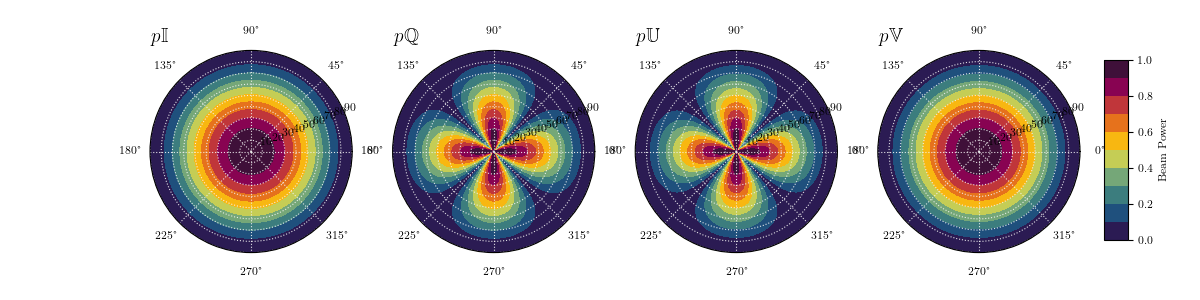

In [12]:
%matplotlib widget
# Plot beams

# Create mesh grid
az_array, za_array = np.meshgrid(
    beam_halfsky_altaz.axis1_array, np.rad2deg(beam_halfsky_altaz.axis2_array)
)

# Create figure with 4 subplots in a row
fig, axes = plt.subplots(
    1, 4, subplot_kw=dict(projection='polar'), figsize=(12, 3)
)

# Titles for each subplot
titles = [r"$p\mathbb{I}$", r"$p\mathbb{Q}$", r"$p\mathbb{U}$", r"$p\mathbb{V}$"]

for i, ax in enumerate(axes):
    ax.grid(True, ls=":", color="whitesmoke", alpha=0.9)

    # Plot contourf
    contourplot = ax.contourf(
        az_array,
        za_array,
        np.real(beam_halfsky_altaz.data_array[0, i, 0]),
        levels=11,
        cmap=cmr.pride,
    )

    # Set title for each subplot
    ax.set_title(titles[i], fontsize=14, loc='left')

# Add a single colorbar for all plots
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])  # Colorbar position
cbar = plt.colorbar(contourplot, cax=cbar_ax, label="Beam Power", orientation="vertical")

plt.show()

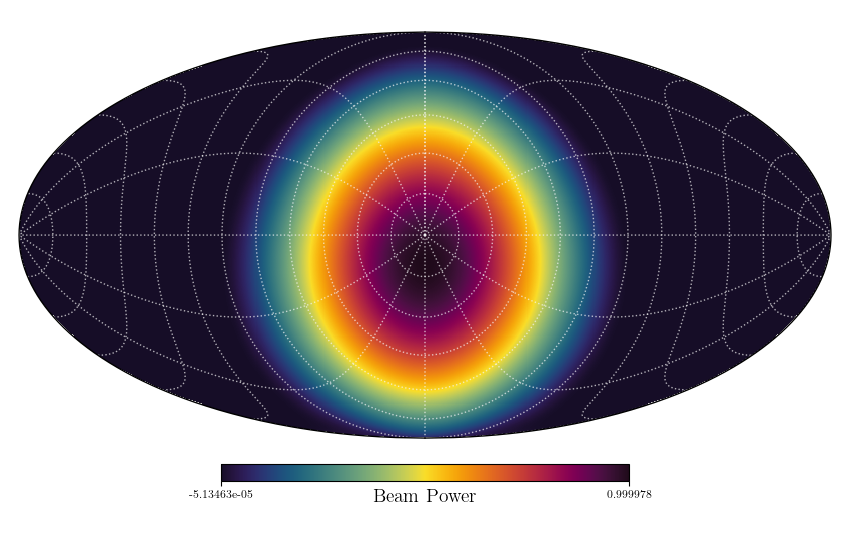

In [13]:
%matplotlib widget

# Define a colormap with 11 discrete colors
colors = cmr.pride(np.linspace(0, 1, 11))
cmap = ListedColormap(colors)

hp.mollview(
    beam_hpx[0, 0, 0],
    rot=(0, 90),
    # cmap=cmap,
    cmap=cmr.pride,
    cbar=True,
    unit='Beam Power',
    title="")

hp.visufunc.graticule(15, 360/12, ls=":", color="whitesmoke", alpha=0.7)
plt.show()

## PyGDSM

In [ ]:
# This may produce artifacts - ud_grade is bad
gsm = GlobalSkyModel(freq_unit='MHz')
gsm_hpx = rotate_healpix_map_galactic_to_icrs(hp.pixelfunc.ud_grade(gsm.generate(uvd.freq_array/1e6), nside))

In [ ]:
with open("data/gsm_hpx.pkl", "wb") as f:
    pkl.dump(gsm_hpx, f)

In [14]:
with open("data/gsm_hpx.pkl", "rb") as f:
    gsm_hpx = pkl.load(f)

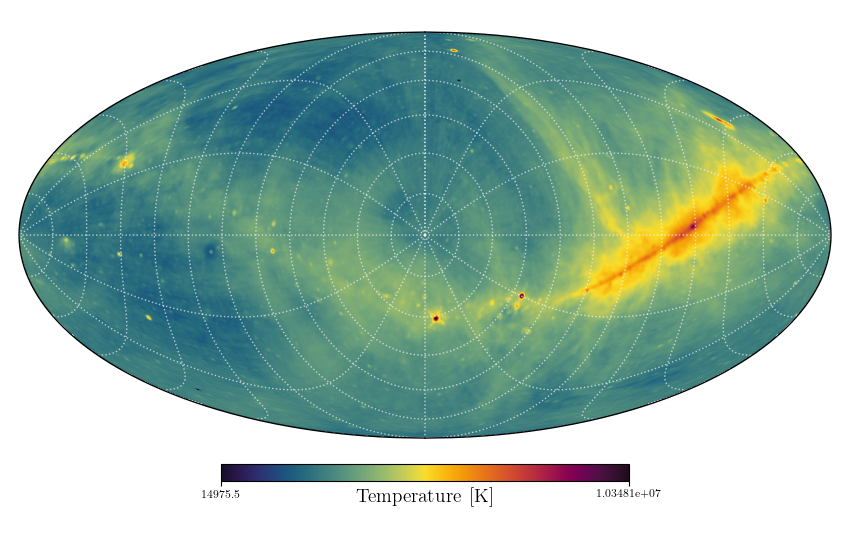

In [15]:
%matplotlib widget

hp.mollview(
    gsm_hpx[0],
    rot=(0, 90),
    cmap=cmr.pride,
    cbar=True,
    norm="log",
    unit='Temperature [K]',
    title="")

hp.visufunc.graticule(15, 360/12, ls=":", color="whitesmoke", alpha=0.7)
plt.show()

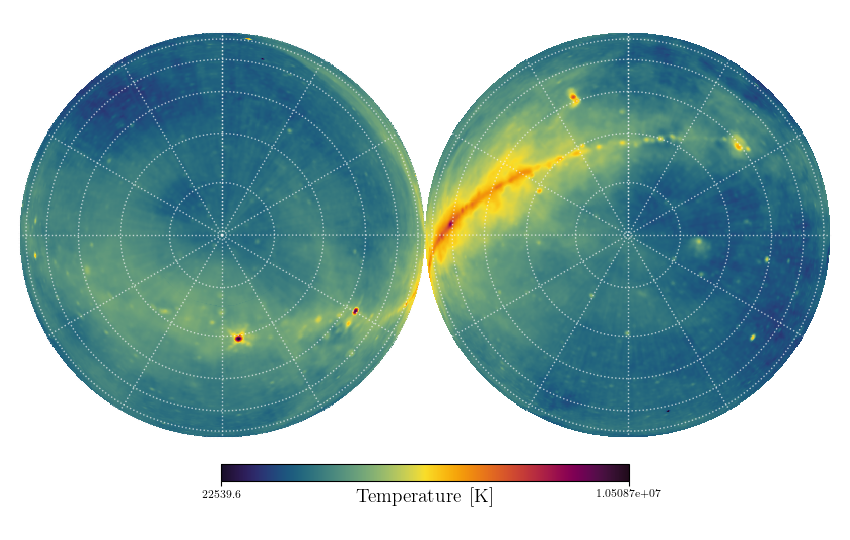

In [16]:
%matplotlib widget

hp.orthview(
    gsm_hpx[0],
    rot=[0, 90],
    cmap=cmr.pride,
    cbar=True,
    norm="log",
    unit='Temperature [K]',
    title="")

hp.visufunc.graticule(15, 360/12, ls=":", color="whitesmoke", alpha=0.7)
plt.show()

## Simulate m-modes

In [17]:
def construct_Bm(
    beam_map: np.ndarray,
    uvd: UVData,
    albatros: EarthLocation,
    freq: float
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Constructs independent m-mode transfer matrices B_m for an interferometric array.

    This function computes the transfer matrices B_m, which encode how 
    m-modes of the sky couple into the visibility domain.

    Parameters
    ----------
    beam_map : np.ndarray
        HEALPix beam response of shape (Npix,), representing the primary beam.
    uvd : UVData
        A UVData object containing antenna positions and baseline information.
    albatros : EarthLocation
        Location of the interferometer for coordinate transformation.
    freq : float
        Observing frequency in Hz.

    Returns
    -------
    Bm : np.ndarray
        An array of shape (2ell_max + 1, Nbls, ell_max + 1), where each 
        slice along the first axis corresponds to a specific m-mode transfer function.
    m_modes : np.ndarray
        Array of m-mode values, shape (2ell_max + 1,).
    baselines : np.ndarray
        Computed baseline vectors in ECI coordinates, shape (Nbls, 3).

    Notes
    -----
    - The `Bm` matrix is indexed such that `Bm[m_idx, bi, l]` represents the contribution
      of spherical harmonic coefficient `a_{lm}` to the visibility of baseline `bi` for mode `m`.
    - The baseline list is preprocessed to **remove duplicate zero-length baselines**,
      but a **single (0,0,0) baseline is retained** at the top for reference.
    - Uses spherical harmonic decomposition (`map2alm`) to transform the beam-fringe product.
    """

    # Determine nside from map
    nside = hp.npix2nside(beam_map.size)
    
    # HEALPix parameters
    ell_max = 3 * nside - 1
    npix = hp.nside2npix(nside)
    n_hat = np.array(hp.pix2vec(nside, np.arange(npix)))  # (3, Npix)

    # Extract ENU antenna positions and their indices from UVData
    enu_antpos, antenna_numbers = uvd.get_ENU_antpos()
    antpairs = uvd.get_antpairs()

    # Convert ENU to ECI
    enu_to_eci = enu_to_eci_matrix(ha=0, lat=albatros.lat.rad)
    eci_antpos = (enu_to_eci @ enu_antpos.T).T
    eci_antpos_dict = dict(zip(antenna_numbers, eci_antpos))

    # Compute baselines while skipping (i, i) pairs
    baselines = np.array([
        eci_antpos_dict[aj] - eci_antpos_dict[ai]
        for ai, aj in antpairs if ai != aj
    ])

    # Add a single (0,0,0) baseline to the top
    zero_baseline = np.zeros((1, 3))  # Shape: (1, 3) for a single zero baseline
    baselines = np.vstack([zero_baseline, baselines])

    # Number of baselines
    Nbls = baselines.shape[0]

    # Define m-modes (ranging from -ell_max to +ell_max)
    m_modes = np.arange(-ell_max, ell_max + 1)
    l_modes = np.arange(ell_max + 1)

    # Precompute geometric delays for all baselines (Nbls, Npix)
    delays = (baselines @ n_hat) / c.c.si.value
    fringe = np.exp(2j * np.pi * freq * delays)

    # Multiply beam by fringe in pixel space (Nbls, Npix)
    beam_transfer = beam_map * fringe

    # Initialize storage for B_m (m_modes, Nbls, l_modes)
    Bm = np.zeros((m_modes.size, Nbls, l_modes.size), dtype=np.complex128)

    # Precompute spherical harmonic decomposition for all baselines
    btr_lm = np.zeros((Nbls, hp.sphtfunc.Alm.getsize(ell_max)), dtype=np.complex128)
    bti_lm = np.zeros((Nbls, hp.sphtfunc.Alm.getsize(ell_max)), dtype=np.complex128)

    for ib in range(Nbls):
        btr_lm[ib] = hp.map2alm(beam_transfer[ib].real, lmax=ell_max, use_pixel_weights=True)
        bti_lm[ib] = hp.map2alm(beam_transfer[ib].imag, lmax=ell_max, use_pixel_weights=True)

    # Precompute m-mode index lookup to avoid np.where() in loops
    m_mode_lookup = {m: i for i, m in enumerate(m_modes)}

    # Iterate over baselines
    for bi in tqdm(range(Nbls), desc="Processing Baselines", colour="#5E4FA1"):

        # Iterate over positive |m|-modes
        for m in range(0, ell_max + 1):
            m_idx_pos = m_mode_lookup[m]
            m_idx_neg = m_mode_lookup[-m]

            # Extract relevant blm values for this m
            l_values = np.arange(m, ell_max + 1)
            bt_lm_indices = hp.sphtfunc.Alm.getidx(ell_max, l_values, m)

            # Assign to +m rows
            Bm[m_idx_pos, bi, m:] = btr_lm[bi][bt_lm_indices] + 1j * bti_lm[bi][bt_lm_indices]

            # Assign to -m rows using symmetry relation
            # Don't double count m=0
            if m > 0:
                Bm[m_idx_neg, bi, m:] = (-1) ** m * (btr_lm[bi][bt_lm_indices].conj() + 1j * bti_lm[bi][bt_lm_indices].conj())

    return Bm, m_modes, baselines

In [18]:
def Bm_svd(Bm: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Computes and stores the SVD decomposition of Bm for efficient Tikhonov regularization.

    Parameters
    ----------
    Bm : np.ndarray
        The m-mode transfer function of shape (2ell_max + 1, Nbls, ell_max + 1).

    Returns
    -------
    U : np.ndarray
        Left singular vectors of shape (2ell_max + 1, Nbls, min(Nbls, ell_max + 1)).
    S : np.ndarray
        Singular values of shape (2ell_max + 1, min(Nbls, ell_max + 1)).
    Vh : np.ndarray
        Right singular vectors (Hermitian) of shape (2ell_max + 1, min(Nbls, ell_max + 1), ell_max + 1).
    """

    m_modes, Nbls, l_modes = Bm.shape
    k = min(Nbls, l_modes)

    # Preallocate arrays for SVD components
    U = np.zeros((m_modes, Nbls, k), dtype=np.complex128)
    S = np.zeros((m_modes, k), dtype=np.float64)
    Vh = np.zeros((m_modes, k, l_modes), dtype=np.complex128)

    for m in tqdm(range(m_modes), desc="m-modes", colour="#5E4FA1"):
        U[m], S[m], Vh[m] = np.linalg.svd(Bm[m], full_matrices=False)

    return U, S, Vh

In [ ]:
%%time
%%memit
Bm, m_modes, bl = construct_Bm(beam_hpx[0, 0, 0], uvd, albatros, 14e6)

In [ ]:
%%time
%%memit
U, S, Vh = Bm_svd(Bm)
Bm_svd = {'U': U, 'S': S, 'Vh': Vh}

In [ ]:
with open("data/Bm.pkl", "wb") as f:
    pkl.dump(Bm, f)
with open("data/Bm_svd.pkl", "wb") as f:
    pkl.dump(Bm_svd, f)
with open("data/m_modes.pkl", "wb") as f:
    pkl.dump(m_modes, f)

In [19]:
with open("data/Bm.pkl", "rb") as f:
    Bm = pkl.load(f)
with open("data/Bm_svd.pkl", "rb") as f:
    Bm_svd = pkl.load(f)
with open("data/m_modes.pkl", "rb") as f:
    m_modes = pkl.load(f)

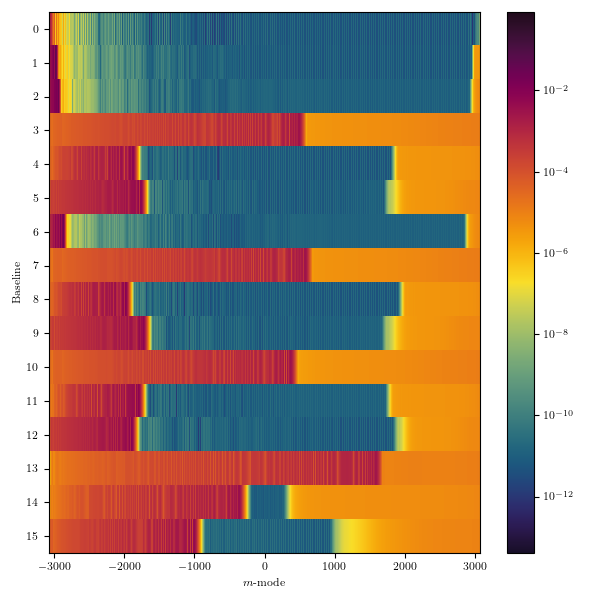

In [20]:
%matplotlib widget

fig, ax = plt.subplots(figsize=(6, 6))

# Plot the matrix with correct extents
im = ax.imshow(
    np.abs(Bm[np.where(m_modes == 0)[0][0]]), 
    cmap=cmr.pride, 
    norm=LogNorm(), 
    extent=(m_modes[0], m_modes[-1], Bm.shape[1], 0),  # Correct y-axis flip
    interpolation='none'
)

# Compute tick positions: center of each row/bin
num_baselines = Bm.shape[1]
ytick_positions = np.arange(num_baselines) + 0.5  # Center of each row
ytick_labels = np.arange(num_baselines)  # Label with baseline indices

# Apply y-ticks
ax.set_yticks(ytick_positions)
ax.set_yticklabels(ytick_labels)

ax.set_xlabel("$m$-mode")
ax.set_ylabel("Baseline")
ax.set_aspect('auto')
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [21]:
def construct_a(sky_map: np.ndarray) -> np.ndarray:
    """
    Constructs the column vector `a` containing the spherical harmonic sky coefficients.

    Parameters
    ----------
    sky_map : np.ndarray
        HEALPix sky brightness temperature map (shape: (Npix,)).

    Returns
    -------
    a : np.ndarray
        Column vector of shape (2ell_max + 1, ell_max + 1), storing sky coefficients `a_{lm}`.
    """

    # Determine nside from map
    nside = hp.npix2nside(sky_map.size)
    
    # HEALPix parameters
    ell_max = 3 * nside - 1

    # Compute spherical harmonic decomposition of the sky
    sky_lm = hp.map2alm(sky_map, lmax=ell_max, use_pixel_weights=True)

    # Define m-modes (ranging from -ell_max to +ell_max)
    m_modes = np.arange(-ell_max, ell_max + 1)
    l_modes = np.arange(ell_max + 1)

    # Initialize storage for a
    a = np.zeros((m_modes.size, l_modes.size), dtype=np.complex128)

    # Precompute m-mode index lookup for efficiency
    m_mode_lookup = {m: i for i, m in enumerate(m_modes)}

    # Iterate over positive m-modes first
    for m in range(0, ell_max + 1):
        l_values = np.arange(m, ell_max + 1)
        sky_lm_indices = hp.sphtfunc.Alm.getidx(ell_max, l_values, m)

        # Get the row index for +m
        m_idx_pos = m_mode_lookup[m]
        m_idx_neg = m_mode_lookup[-m]
        
        a[m_idx_pos, m:] = sky_lm[sky_lm_indices]

        if m > 0:
            a[m_idx_neg, m:] = (-1) ** m * sky_lm[sky_lm_indices].conj()

    return a

In [ ]:
%%time
%%memit
a = construct_a(gsm_hpx[0])

In [ ]:
%%time
%%memit
vm = np.einsum("mbl,ml->mb", Bm, a, optimize=True)

In [ ]:
with open("data/a.pkl", "wb") as f:
    pkl.dump(a, f)
with open("data/vm.pkl", "wb") as f:
    pkl.dump(vm, f)

In [22]:
with open("data/a.pkl", "rb") as f:
    a = pkl.load(f)
with open("data/vm.pkl", "rb") as f:
    vm = pkl.load(f)

In [23]:
n_m = m_modes.size
d_m = m_modes[1] - m_modes[0]
phi = np.fft.fftshift(np.fft.fftfreq(n_m, d_m) * 2 * np.pi) 
d_t = np.fft.fftshift(np.fft.fftfreq(n_m, d_m) * sidereal)/(3600)
v_phi = np.fft.ifft(np.fft.ifftshift(vm, axes=0), axis=0).T

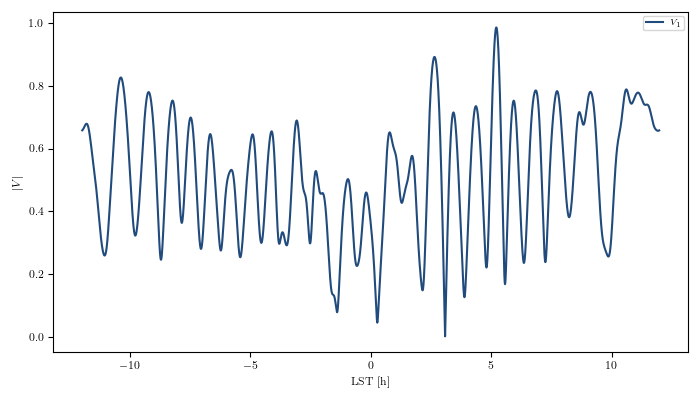

In [24]:
%matplotlib widget

fig, ax = plt.subplots(figsize=(7, 4))

colors = cmr.pride(np.linspace(0.1, 0.9, 21))

# Nbls = bl.shape[0]
# for i in range(Nbls):
#     # if i > 0:
#     ax.plot(d_t, np.abs(v_phi[i]), color=colors[i], label=f"$V_{{{i}}}$")

b = 1
ax.plot(d_t, np.abs(v_phi[b]), color=colors[b], label=f"$V_{{{b}}}$")

ax.set_xlabel('LST [h]')
ax.set_ylabel('$|V|$')
# ax.set_yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
P_m = np.sum(np.abs(Bm) ** 2, axis=2)

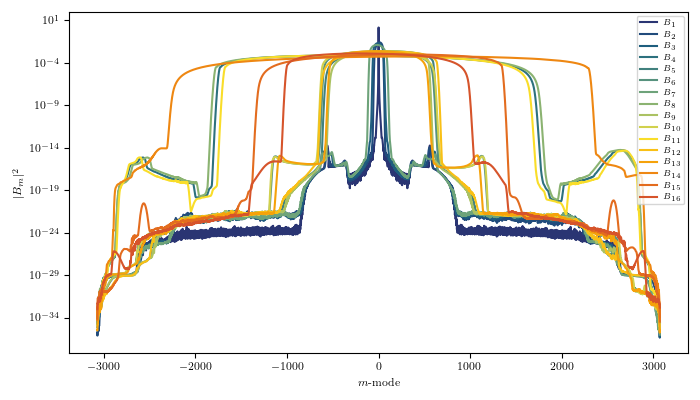

In [26]:
%matplotlib widget

fig, ax = plt.subplots(figsize=(7, 4))

colors = cmr.pride(np.linspace(0.1, 0.9, 21))

for i, p in enumerate(P_m.T):
    ax.plot(m_modes, p, color=colors[i], label=f"$B_{{{i+1}}}$")

ax.set_yscale('log')
ax.set_xlabel('$m$-mode')
ax.set_ylabel('$|B_m|^2$')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [27]:
def optimize_tikhonov_reqularization(U: np.ndarray, S: np.ndarray, Vh: np.ndarray, vm: np.ndarray, epsilons: list) -> tuple:
    """
    Computes the Tikhonov-regularized solution using precomputed SVD for all m-modes.

    Parameters
    ----------
    U : np.ndarray
        Left singular vectors of shape (2ell_max + 1, Nbls, k).
    S : np.ndarray
        Singular values of shape (2ell_max + 1, k).
    Vh : np.ndarray
        Right singular vectors (Hermitian) of shape (2ell_max + 1, k, ell_max + 1).
    vm : np.ndarray
        The measured m-mode visibilities of shape (2ell_max + 1, Nbls).
    epsilons : list
        List of Tikhonov regularization parameters.

    Returns
    -------
    norms_a : np.ndarray
        Array of solution norms ||a|| for each epsilon.
    norms_residual : np.ndarray
        Array of residual norms ||vm - Bm a|| for each epsilon.
    """

    m_modes, k = S.shape  # Number of m-modes and singular values
    norms_a = np.zeros(len(epsilons))  # Store total ||a||
    norms_residual = np.zeros(len(epsilons))  # Store total ||v_m - B_m a||

    for i, epsilon in enumerate(epsilons):
        print(f'epsilon: [ {epsilon} ]')
        total_norm_a = 0
        total_norm_residual = 0

        for m in tqdm(range(m_modes), desc="m-modes", colour="#5E4FA1"):
            # Compute regularized inverse of singular values
            S_inv_reg = np.diag(S[m] / (S[m]**2 + epsilon))

            # Compute a_Tikhonov for this m-mode
            Ut_vm = U[m].conj().T @ vm[m]
            a_tikh_m = Vh[m].conj().T @ S_inv_reg @ Ut_vm  # Shape: (l_modes,)

            # Compute norms and sum over all m-modes
            total_norm_a += np.linalg.norm(a_tikh_m)**2  # ||a||^2
            residual_m = np.linalg.norm(vm[m] - (U[m] @ np.diag(S[m]) @ Vh[m]) @ a_tikh_m)**2
            total_norm_residual += residual_m  # ||vm - Bm a||^2

        # Convert summed squared norms to final norms
        norms_a[i] = np.sqrt(total_norm_a)
        norms_residual[i] = np.sqrt(total_norm_residual)

    return norms_a, norms_residual

In [28]:
%%time
epsilons = np.logspace(2, -6, num=8, endpoint=False)
norms_a, nomrs_residual = optimize_tikhonov_reqularization(Bm_svd['U'], Bm_svd['S'], Bm_svd['Vh'], vm, epsilons)

epsilon: [ 100.0 ]


m-modes:   0%|          | 0/6143 [00:00<?, ?it/s]

epsilon: [ 10.0 ]


m-modes:   0%|          | 0/6143 [00:00<?, ?it/s]

epsilon: [ 1.0 ]


...

epsilon: [ 0.0001 ]


m-modes:   0%|          | 0/6143 [00:00<?, ?it/s]

epsilon: [ 1e-05 ]


m-modes:   0%|          | 0/6143 [00:00<?, ?it/s]

CPU times: user 19.6 s, sys: 18 s, total: 37.6 s
Wall time: 31.2 s


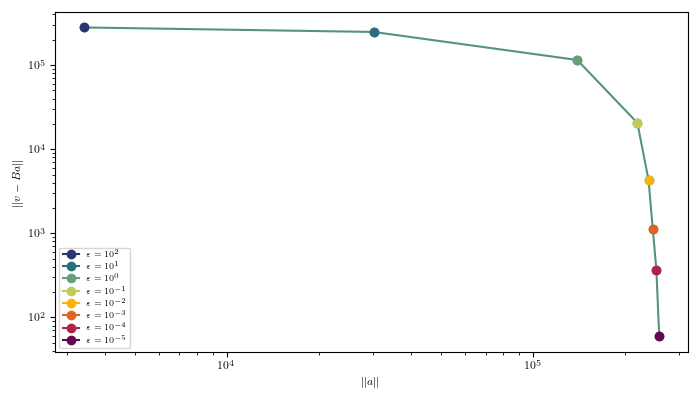

In [29]:
%matplotlib widget

fig, ax = plt.subplots(figsize=(7, 4))


ax.plot(norms_a, nomrs_residual, '-o', color=cmr.pride([0.3]))

colors = cmr.pride(np.linspace(0.1, 0.9, epsilons.size))
for i, e in enumerate(epsilons):
    ax.plot(norms_a[i], nomrs_residual[i], '-o', color=colors[i], label=rf'$\varepsilon = 10^{{{int(np.log10(e))}}}$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$||a||$')
ax.set_ylabel(r'$||v - Ba||$')

plt.legend()
plt.tight_layout()
plt.show()

In [30]:
def tikhonov_regularization_svd(U: np.ndarray, S: np.ndarray, Vh: np.ndarray, vm: np.ndarray, epsilon: float, use_tqdm: bool = True) -> np.ndarray:
    """
    Solves for a_Tikhonov using precomputed SVD of Bm.

    Parameters
    ----------
    U : np.ndarray
        Left singular vectors of shape (2ell_max + 1, Nbls, k).
    S : np.ndarray
        Singular values of shape (2ell_max + 1, k).
    Vh : np.ndarray
        Right singular vectors (Hermitian) of shape (2ell_max + 1, k, ell_max + 1).
    vm : np.ndarray
        The measured m-mode visibilities of shape (2ell_max + 1, Nbls).
    epsilon : float
        The Tikhonov regularization parameter.
    use_tqdm : bool, optional
        If True, use tqdm to show progress; otherwise, use a standard loop (default: True).

    Returns
    -------
    a_tikh : np.ndarray
        The Tikhonov-regularized spherical harmonic coefficients of shape (2ell_max + 1, ell_max + 1).
    """

    m_modes, k = S.shape  # Number of m-modes and singular values
    l_modes = Vh.shape[2]  # Number of spherical harmonic modes

    # Allocate storage for the solution
    a_tikh = np.zeros((m_modes, l_modes), dtype=np.complex128)

    iterator = tqdm(range(m_modes), desc="m-modes", colour="#5E4FA1") if use_tqdm else range(m_modes)

    for m in iterator:
        # Compute regularized inverse of singular values
        S_inv_reg = np.diag(S[m] / (S[m] ** 2 + epsilon))

        # Compute a_Tikhonov using SVD decomposition
        a_tikh[m] = Vh[m].conj().T @ S_inv_reg @ (U[m].conj().T @ vm[m])

    return a_tikh

In [ ]:
a_tikh = tikhonov_regularization_svd(Bm_svd['U'], Bm_svd['S'], Bm_svd['Vh'], vm, epsilon=1e-3)

In [ ]:
with open("data/a_tikh.pkl", "wb") as f:
    pkl.dump(a_tikh, f)

In [31]:
with open("data/a_tikh.pkl", "rb") as f:
    a_tikh = pkl.load(f)

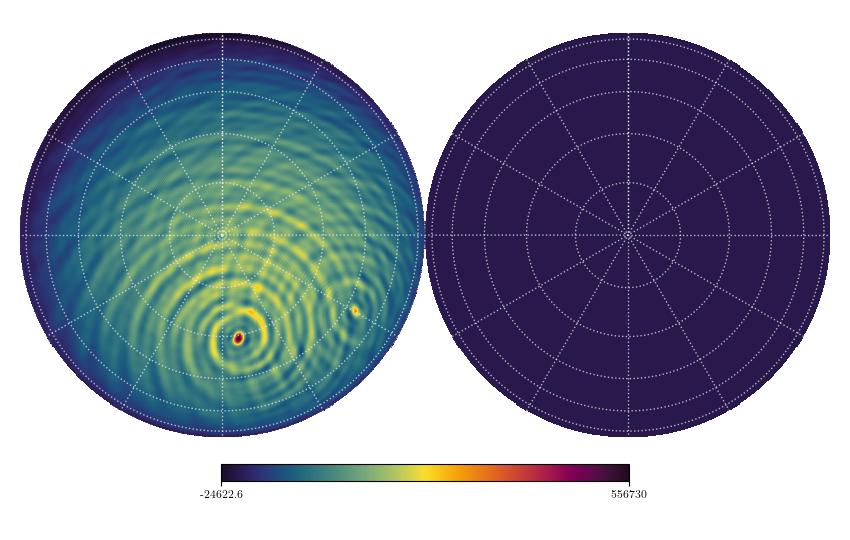

In [32]:
%matplotlib widget

lmax = 3 * nside - 1
    
# Convert m-mode coefficients to full spherical harmonics `alm`
alm = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)

for m in range(-lmax, lmax + 1):
    m_idx = m + lmax  # Shift index to be positive
    l_values = np.arange(max(0, abs(m)), lmax + 1)  # Only valid `l` values

    # Get HEALPix alm indices
    alm_indices = hp.Alm.getidx(lmax, l_values, abs(m))

    # Ensure correct shape
    values = a_tikh[m_idx, max(0, abs(m)) : max(0, abs(m)) + len(l_values)]

    # Assign values (taking complex conjugate symmetry into account)
    if m >= 0:
        alm[alm_indices] = values
    else:
        alm[alm_indices] = (-1) ** abs(m) * np.conj(values)

# Convert spherical harmonics to a HEALPix map
sky_map = hp.alm2map(alm, nside=nside, lmax=lmax)

# hp.mollview(sky_map, cmap=cmr.pride)

hp.orthview(
    sky_map,
    rot=[0, 90],
    cmap=cmr.pride,
    cbar=True,
    # norm="log",
    # unit='Temperature [K]',
    title="")

hp.visufunc.graticule(15, 360/12, ls=":", color="whitesmoke", alpha=0.7)
plt.show()

## Estimate PSF as a function of declination
This esentially repeats the complete simulation and regularization step, with an sky model with a single point souce at a particular declination and RA=0

In [33]:
def tikhonov_regularization_svd_psf(U: np.ndarray, S: np.ndarray, Vh: np.ndarray, aps: np.ndarray, epsilon: float, use_tqdm: bool = True) -> np.ndarray:
    """
    Solves for a_Tikhonov using precomputed SVD of Bm.

    Parameters
    ----------
    U : np.ndarray
        Left singular vectors of shape (2ell_max + 1, Nbls, k).
    S : np.ndarray
        Singular values of shape (2ell_max + 1, k).
    Vh : np.ndarray
        Right singular vectors (Hermitian) of shape (2ell_max + 1, k, ell_max + 1).
    aps : np.ndarray
        The measured m-modes of a single point source of shape (2ell_max + 1, Nbls).
    epsilon : float
        The Tikhonov regularization parameter.
    use_tqdm : bool, optional
        If True, use tqdm to show progress; otherwise, use a standard loop (default: True).

    Returns
    -------
    a_tikh : np.ndarray
        The Tikhonov-regularized spherical harmonic coefficients of shape (2ell_max + 1, ell_max + 1).
    """

    m_modes, k = S.shape  # Number of m-modes and singular values
    l_modes = Vh.shape[2]  # Number of spherical harmonic modes

    # Allocate storage for the solution
    a_tikh = np.zeros((m_modes, l_modes), dtype=np.complex128)

    iterator = tqdm(range(m_modes), desc="m-modes", colour="#5E4FA1") if use_tqdm else range(m_modes)

    for m in iterator:
        # Compute regularized inverse of singular values
        S_inv_reg = np.diag(S[m] ** 2 / (S[m] ** 2 + epsilon))

        # Compute a_Tikhonov using SVD decomposition
        a_tikh[m] = Vh[m].conj().T @ S_inv_reg @ Vh[m] @ aps[m]

    return a_tikh

In [34]:
def point_map(nside: int, ra: float, dec: float) -> np.ndarray:
    """
    Creates a HEALPix map with a single pixel set to 100 at a given RA and Dec.

    Parameters
    ----------
    nside : int
        HEALPix resolution parameter (must be a power of 2).
    ra : float
        Right Ascension (RA) in degrees.
    dec : float
        Declination (Dec) in degrees.

    Returns
    -------
    np.ndarray
        A HEALPix map (1D NumPy array) with a single pixel set to 100.
    
    Notes
    -----
    - Uses `hp.ang2pix()` to convert (RA, Dec) to HEALPix pixel index.
    - HEALPix uses **colatitude** instead of latitude:
      - `theta = 90 - dec` (convert from Declination).
      - `phi = ra` (RA is already a longitude-like angle).
    """
    
    point_hpx = np.zeros(hp.nside2npix(nside))  # Initialize HEALPix map
    theta = np.deg2rad(90 - dec)  # Convert Dec to colatitude (0 = North Pole)
    phi = np.deg2rad(ra)  # RA directly maps to longitude
    
    point_idx = hp.ang2pix(nside, theta, phi)
    point_hpx[point_idx] = 1
    
    return point_hpx

In [ ]:
aps_hpx = point_map(nside, 0, 90)
aps = construct_a(aps_hpx)
a_tikh_point = tikhonov_regularization_svd_psf(Bm_svd['U'], Bm_svd['S'], Bm_svd['Vh'], aps, epsilon=1e-3)

In [ ]:
%matplotlib widget

lmax = 3 * nside - 1

# Convert m-mode coefficients to full spherical harmonics `alm`
alm = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)

for m in range(-lmax, lmax + 1):
    m_idx = m + lmax  # Shift index to be positive
    l_values = np.arange(max(0, abs(m)), lmax + 1)  # Only valid `l` values

    # Get HEALPix alm indices
    alm_indices = hp.Alm.getidx(lmax, l_values, abs(m))

    # Ensure correct shape
    values = a_tikh_point[m_idx, max(0, abs(m)) : max(0, abs(m)) + len(l_values)]

    # Assign values (taking complex conjugate symmetry into account)
    if m >= 0:
        alm[alm_indices] = values
    else:
        alm[alm_indices] = (-1) ** abs(m) * np.conj(values)

# Convert spherical harmonics to a HEALPix map
sky_map_point = hp.alm2map(alm, nside=nside, lmax=lmax)

# hp.mollview(sky_map, cmap=cmr.pride)

hp.orthview(
    sky_map_point,
    rot=[0, 90],
    cmap=cmr.pride,
    cbar=True)

hp.visufunc.graticule(15, 360/12, ls=":", color="whitesmoke", alpha=0.7)
plt.show()

In [ ]:
%matplotlib widget

reso = hp.nside2resol(nside, arcmin=True)
xsize = int(4 * 60 / reso)
hp.gnomview(sky_map_point, rot=(0, 90), reso=reso, xsize=xsize, cmap=cmr.pride)

plt.show()

In [ ]:
psfs = {}
lmax = 3 * nside - 1

for i, dec in enumerate(np.arange(0, 90, 10)):
    aps_hpx = point_map(nside, 0, dec)
    aps = construct_a(aps_hpx)
    a_tikh_point = tikhonov_regularization_svd_psf(Bm_svd['U'], Bm_svd['S'], Bm_svd['Vh'], aps, epsilon=1e-3)
    
    alm = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)
    
    for m in range(-lmax, lmax + 1):
        m_idx = m + lmax  # Shift index to be positive
        l_values = np.arange(max(0, abs(m)), lmax + 1)  # Only valid `l` values
    
        # Get HEALPix alm indices
        alm_indices = hp.Alm.getidx(lmax, l_values, abs(m))
    
        # Ensure correct shape
        values = a_tikh_point[m_idx, max(0, abs(m)) : max(0, abs(m)) + len(l_values)]
    
        # Assign values (taking complex conjugate symmetry into account)
        if m >= 0:
            alm[alm_indices] = values
        else:
            alm[alm_indices] = (-1) ** abs(m) * np.conj(values)
    
    # Convert spherical harmonics to a HEALPix map
    sky_map_point = hp.alm2map(alm, nside=nside, lmax=lmax)
    psfs[f"{dec}"] = sky_map_point

In [ ]:
with open("data/psfs.pkl", "wb") as f:
    pkl.dump(psfs, f)

In [35]:
with open("data/psfs.pkl", "rb") as f:
    psfs = pkl.load(f)

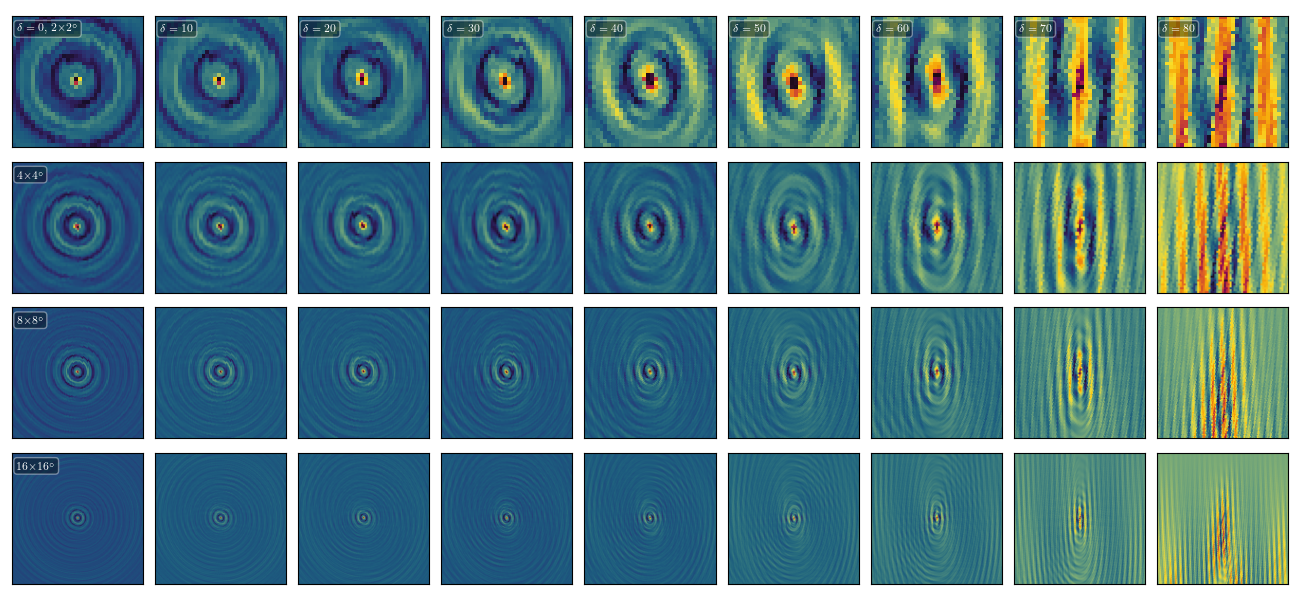

In [36]:
%matplotlib widget

fig, axs = plt.subplots(ncols=9, nrows=4, figsize=(13, 6))

reso = hp.nside2resol(nside, arcmin=True)

for i, dec in enumerate(np.arange(0, 90, 10)):
    for j, x in enumerate([2, 4, 8, 16]):
        xsize = int(x * 60 / reso)
        d_psf = hp.gnomview(psfs[f"{dec}"], rot=(0, dec), reso=reso, xsize=xsize, return_projected_map=True, no_plot=True)
        
        axs[j, 8-i].imshow(d_psf, cmap=cmr.pride, aspect="equal")
        axs[j, 8-i].set_xticks([])
        axs[j, 8-i].set_yticks([])

        if j == 0:
            if i == 0:
                axs[j, i].text(
                    0.04, 0.88, rf"$\delta={dec}$, {x}$\times${x}$^\circ$",
                    transform=axs[j, i].transAxes,
                    fontsize=8, color="white",
                    bbox=dict(facecolor="black", alpha=0.4, edgecolor="w", boxstyle="round,pad=0.3")
            )
            else:
                axs[j, i].text(
                0.04, 0.88, rf"$\delta={dec}$",
                transform=axs[j, i].transAxes,
                fontsize=8, color="white",
                bbox=dict(facecolor="black", alpha=0.4, edgecolor="w", boxstyle="round,pad=0.3")
            )
            

        if i == 8:
            if j > 0:
                axs[j, 8-i].text(
                    0.04, 0.88, rf"{x}$\times${x}$^\circ$",
                    transform=axs[j, 8-i].transAxes,
                    fontsize=8, color="white",
                    bbox=dict(facecolor="black", alpha=0.4, edgecolor="w", boxstyle="round,pad=0.3")
                )

plt.tight_layout()
plt.show()